### Import Required Libraries


In [3]:
import pandas as pd
import numpy as np

from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

### Data Cleaning and Exploration

In [4]:
# Load datasets
transactions = pd.read_csv("trans.csv")

# Quick overview
print(transactions.shape)

transactions.head()

(1048575, 11)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,1/9/22 00:20,10,8000EBD30,10,8000EBD30,"3,697.34",US Dollar,"3,697.34",US Dollar,Reinvestment,0
1,1/9/22 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,1/9/22 00:00,3209,8000F4670,3209,8000F4670,"14,675.57",US Dollar,"14,675.57",US Dollar,Reinvestment,0
3,1/9/22 00:02,12,8000F5030,12,8000F5030,"2,806.97",US Dollar,"2,806.97",US Dollar,Reinvestment,0
4,1/9/22 00:06,10,8000F5200,10,8000F5200,"36,682.97",US Dollar,"36,682.97",US Dollar,Reinvestment,0


In [5]:
## Check for null values
transactions.isnull().sum().sort_values(ascending=False)

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

In [6]:
## Duplicate Transaction Detection
duplicate_rows = transactions.duplicated()
transactions[duplicate_rows]
transactions[duplicate_rows].sort_values("Timestamp")

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
855417,1/9/22 16:20,12004,800C927C1,12004,800C927C0,0.00,Bitcoin,0.08,Euro,ACH,0
856420,1/9/22 16:20,12004,800C927C1,220,813D8C1E1,0.00,Bitcoin,0.00,Bitcoin,Bitcoin,0


In [7]:
# Drop duplicates, keeping the first occurrence (default behavior)
transactions_unique = transactions.drop_duplicates()

In [8]:
## Data Type Validation
transactions_unique.dtypes

Timestamp                 str
From Bank               int64
Account                   str
To Bank                 int64
Account.1                 str
Amount Received       float64
Receiving Currency        str
Amount Paid           float64
Payment Currency          str
Payment Format            str
Is Laundering           int64
dtype: object

In [9]:
## Invalid Value Checks
invalid_amounts = transactions_unique[
    (transactions_unique["Amount Paid"] <= 0) |
    (transactions_unique["Amount Received"] <= 0)
]
invalid_amounts

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering


In [10]:
## Transformation of TimeStamp Data
transactions_unique["Timestamp"] = pd.to_datetime(transactions_unique["Timestamp"], format="%d/%m/%y %H:%M",errors="coerce")

invalid_timestamps = transactions_unique[transactions_unique["Timestamp"].isnull()]
invalid_timestamps

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering


In [11]:
## Outlier Detection
# Z-score method
transactions_unique["amount_zscore"] = (
    (transactions_unique["Amount Paid"] - transactions_unique["Amount Paid"].mean()) /
    transactions_unique["Amount Paid"].std()
)

outliers = transactions_unique[abs(transactions_unique["amount_zscore"]) > 3]
outliers

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,amount_zscore
40626,2022-09-01 00:26:00,113744,805B75490,14325,805B756C0,"1,561,370,086.00",US Dollar,"1,561,370,086.00",US Dollar,Cheque,0,3.31
79139,2022-09-01 00:10:00,111443,806A0E720,28255,80CF5FE00,"1,674,610,756.00",US Dollar,"1,674,610,756.00",US Dollar,Cheque,0,3.55
79141,2022-09-01 00:10:00,111443,806A0E720,28255,80CF5FE00,"5,351,188,959.00",US Dollar,"5,351,188,959.00",US Dollar,Cash,0,11.38
143096,2022-09-01 00:14:00,25768,80322AD70,27241,80322AE60,"1,779,060,719.00",Euro,"1,779,060,719.00",Euro,ACH,0,3.78
185473,2022-09-01 00:22:00,3123,8052A12C0,30697,811648850,"1,560,938,412.00",Euro,"1,560,938,412.00",Euro,Cheque,0,3.31
...,...,...,...,...,...,...,...,...,...,...,...,...
1042700,2022-09-01 21:54:00,112637,8053C22F0,71,8059B9B60,"7,572,542,016.00",Rupee,"7,572,542,016.00",Rupee,ACH,0,16.11
1043050,2022-09-01 21:43:00,16787,806364380,16787,806364380,"1,420,260,943.00",Ruble,"1,420,260,943.00",Ruble,Reinvestment,0,3.01
1043431,2022-09-01 21:41:00,4,8065D5730,217641,8.07E+65,"4,718,054,545.00",Ruble,"4,718,054,545.00",Ruble,Cheque,0,10.03
1043469,2022-09-01 21:31:00,4,806E27CF0,4,8074AA530,"1,804,645,159.00",Ruble,"1,804,645,159.00",Ruble,Cheque,0,3.83


In [13]:
transactions_unique["Is Laundering"].value_counts()

Is Laundering
0    1047958
1        615
Name: count, dtype: int64

In [66]:
## Categorical Sanity Checks
transactions_unique["Receiving Currency"].value_counts()

Receiving Currency
US Dollar            389782
Euro                 242882
Swiss Franc           48954
Yuan                  43241
Shekel                40251
Rupee                 39839
UK Pound              36326
Yen                   32616
Ruble                 32191
Bitcoin               29802
Canadian Dollar       28591
Australian Dollar     28205
Mexican Peso          23318
Saudi Riyal           17970
Brazil Real           14605
Name: count, dtype: int64

In [67]:
## Categorical Sanity Checks
transactions_unique["Payment Currency"].value_counts()

Payment Currency
US Dollar            391840
Euro                 242357
Swiss Franc           48550
Yuan                  44180
Shekel                39896
Rupee                 39628
UK Pound              36228
Yen                   32482
Ruble                 31918
Bitcoin               29527
Canadian Dollar       28463
Australian Dollar     27981
Mexican Peso          23183
Saudi Riyal           17837
Brazil Real           14503
Name: count, dtype: int64

In [68]:
## Categorical Sanity Checks
transactions_unique["Payment Format"].value_counts()

Payment Format
Reinvestment    459847
Cheque          237592
Credit Card     155043
ACH              81071
Cash             61959
Bitcoin          29532
Wire             23529
Name: count, dtype: int64

In [69]:
## Target Distribution ``
transactions_unique["Is Laundering"].value_counts(normalize=True)

Is Laundering
0   1.00
1   0.00
Name: proportion, dtype: float64

In [70]:
## Summary Statistics
transactions_unique.groupby("Is Laundering")["Amount Paid"].describe()

,count,mean,std,min,25%,50%,75%,max
Is Laundering,,,,,,,,
0,"1,047,958.00","5,776,603.08","457,793,297.68",0.00,101.69,"1,925.73","24,702.99","284,383,000,000.00"
1,615.00,"246,891,582.12","4,341,606,726.11",0.27,"2,854.43","8,784.93","17,718.57","84,853,144,180.00"


In [71]:
## Statistical Test
normal = transactions_unique[transactions_unique["Is Laundering"]==0]["Amount Paid"]
launder = transactions_unique[transactions_unique["Is Laundering"]==1]["Amount Paid"]

stat, p = mannwhitneyu(normal, launder, alternative="two-sided")
print("p-value:", p)

p-value: 9.845528703383399e-29


In [72]:
##Cohen's d

mean_diff = launder.mean() - normal.mean()
pooled_std = np.sqrt(
    (launder.var() + normal.var()) / 2
)

cohens_d = mean_diff / pooled_std
print("Cohen's d:", cohens_d)

Cohen's d: 0.0781065985415696


In [73]:
## Effect Size
transactions_unique.groupby("Is Laundering")["Amount Paid"].median()

Is Laundering
0   1,925.73
1   8,784.93
Name: Amount Paid, dtype: float64

In [74]:
## Correlation With Target
transactions_unique[["Amount Paid","Is Laundering"]].corr()

,Amount Paid,Is Laundering
Amount Paid,1.00,0.01
Is Laundering,0.01,1.00


In [75]:
## Convert object to category (memory optimization)
categorical_cols = [
    "From Bank",
    "To Bank",
    "Receiving Currency",
    "Payment Currency",
    "Payment Format"
]

transactions_unique[categorical_cols] = transactions_unique[categorical_cols].astype("category")

In [76]:
## Convert target column to binary type
transactions_unique["Is Laundering"] = transactions_unique["Is Laundering"].astype("int8")

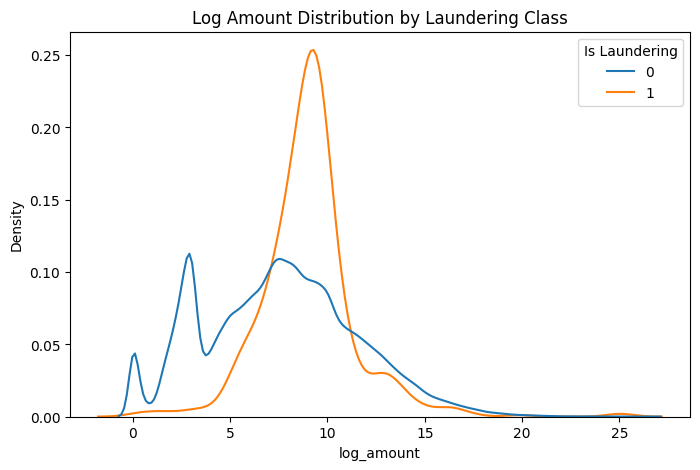

In [77]:
##Visual Comparision of Laundering vs Normal

transactions_unique["log_amount"] = np.log1p(transactions_unique["Amount Paid"])

plt.figure(figsize=(8,5))
sns.kdeplot(
    data=transactions_unique,
    x="log_amount",
    hue="Is Laundering",
    common_norm=False
)
plt.title("Log Amount Distribution by Laundering Class")
plt.show()

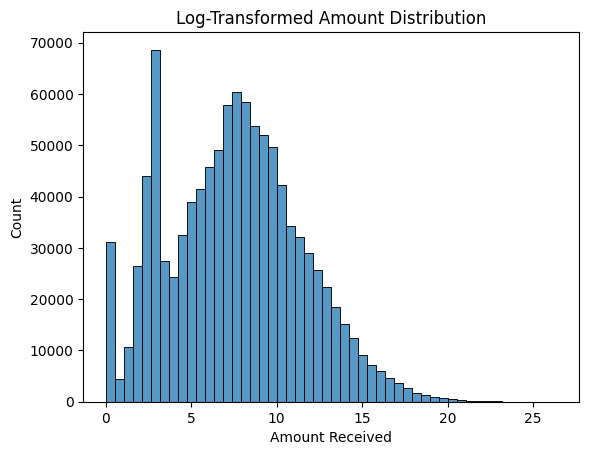

In [78]:
## Transaction Amount Distribution

sns.histplot(np.log1p(transactions_unique["Amount Received"]), bins=50)
plt.title("Log-Transformed Amount Distribution")
plt.show()

In [79]:
transactions_unique["date"] = transactions_unique["Timestamp"].dt.date

txn_per_day = transactions_unique.groupby(["Account","date"]).size().reset_index(name="daily_txn_count")
txn_per_day

,Account,date,daily_txn_count
0,1.00E+14,2022-09-01,1158
1,100428660,2022-09-01,21183
2,1004286A8,2022-09-01,12774
3,1004286F0,2022-09-01,2296
4,100428738,2022-09-01,1701
...,...,...,...
404096,814965980,2022-09-01,1
404097,8149659D0,2022-09-01,2
404098,814965AB0,2022-09-01,2
404099,814965B00,2022-09-01,4


In [80]:
account_velocity = txn_per_day.groupby("Account")["daily_txn_count"].mean()
account_velocity

Account
1.00E+14     1,158.00
100428660   21,183.00
1004286A8   12,774.00
1004286F0    2,296.00
100428738    1,701.00
               ...   
814965980        1.00
8149659D0        2.00
814965AB0        2.00
814965B00        4.00
814965B51        6.00
Name: daily_txn_count, Length: 403873, dtype: float64

In [81]:
## Average Transaction Size per Account
transactions["log_amount_received"] = np.log1p(
    transactions["Amount Received"]
)

avg_txn = (
    transactions
    .groupby("Account")["log_amount_received"]
    .mean()
)

avg_txn

Account
1.00E+14    10.59
100428660    7.60
1004286A8    7.35
1004286F0    9.28
100428738   12.02
             ... 
814965980    5.85
8149659D0    9.05
814965AB0    7.64
814965B00    7.56
814965B51    0.36
Name: log_amount_received, Length: 403873, dtype: float64

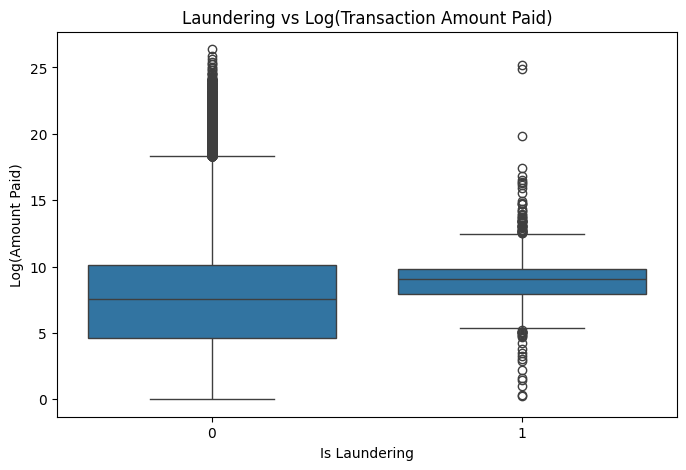

In [82]:
transactions["log_amount_paid"] = np.log1p(transactions["Amount Paid"])

plt.figure(figsize=(8,5))
sns.boxplot(x="Is Laundering", y="log_amount_paid", data=transactions)
plt.title("Laundering vs Log(Transaction Amount Paid)")
plt.xlabel("Is Laundering")
plt.ylabel("Log(Amount Paid)")
plt.show()

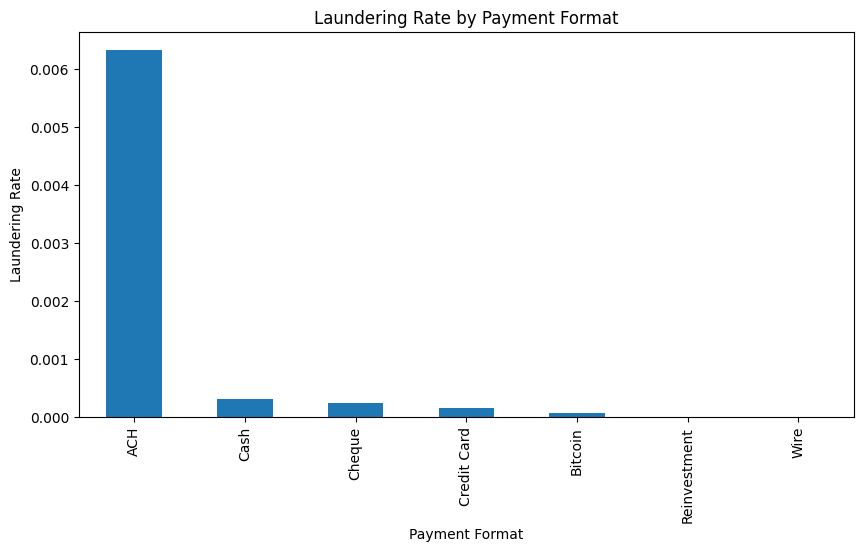

In [83]:
format_rate = (
    transactions
    .groupby("Payment Format")["Is Laundering"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
format_rate.plot(kind="bar")
plt.title("Laundering Rate by Payment Format")
plt.ylabel("Laundering Rate")
plt.show()

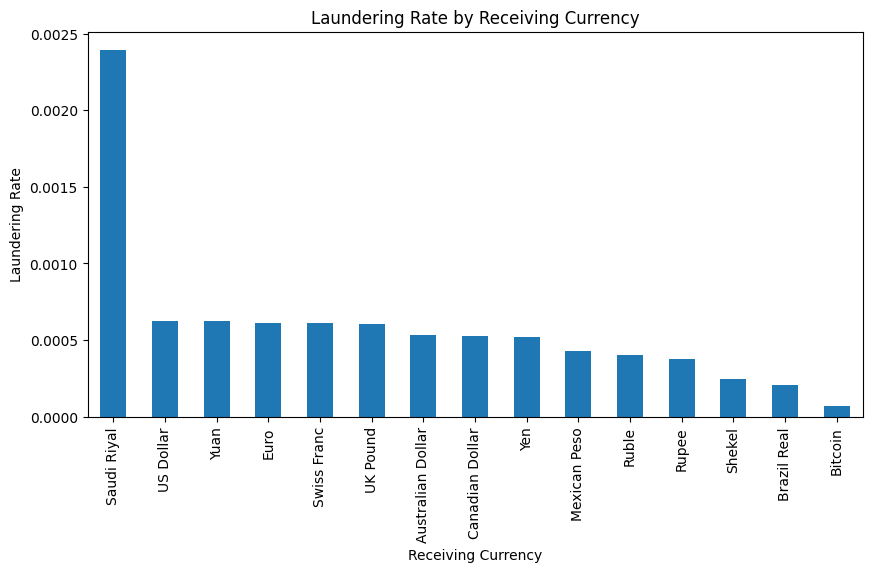

In [84]:
currency_rate = (
    transactions
    .groupby("Receiving Currency")["Is Laundering"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
currency_rate.plot(kind="bar")
plt.title("Laundering Rate by Receiving Currency")
plt.ylabel("Laundering Rate")
plt.show()

/var/folders/8k/_nzqppzx1m7fzvp45mgsr75h0000gn/T/ipykernel_18707/3914131387.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  transactions["Timestamp"] = pd.to_datetime(transactions["Timestamp"])


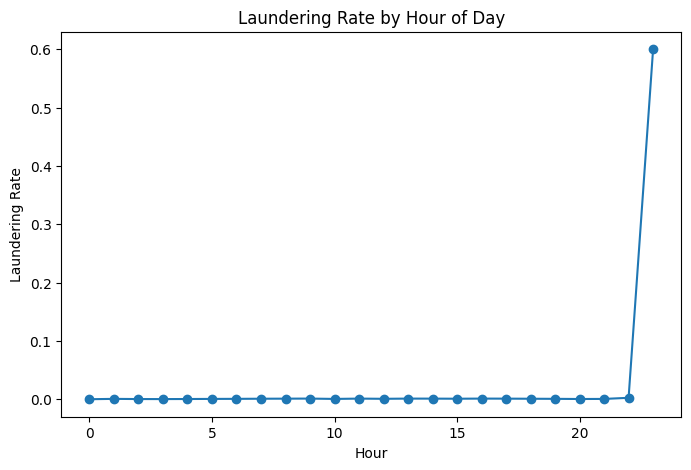

In [85]:
transactions["Timestamp"] = pd.to_datetime(transactions["Timestamp"])
transactions["hour"] = transactions["Timestamp"].dt.hour

hour_rate = (
    transactions
    .groupby("hour")["Is Laundering"]
    .mean()
)

plt.figure(figsize=(8,5))
hour_rate.plot(marker="o")
plt.title("Laundering Rate by Hour of Day")
plt.ylabel("Laundering Rate")
plt.xlabel("Hour")
plt.show()

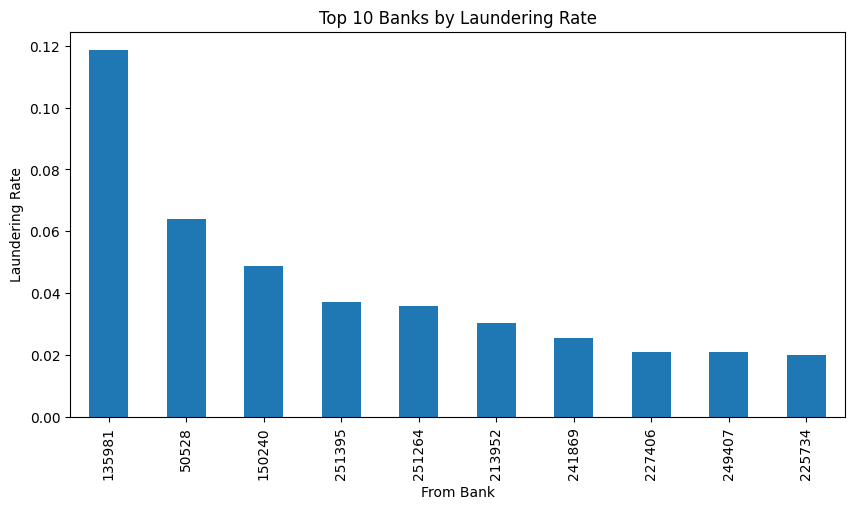

In [86]:
bank_rate = (
    transactions
    .groupby("From Bank")["Is Laundering"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
bank_rate.plot(kind="bar")
plt.title("Top 10 Banks by Laundering Rate")
plt.ylabel("Laundering Rate")
plt.show()

In [87]:
## Counterparty Diversity
counterparty_count = transactions.groupby("Account")["Account.1"].nunique()
counterparty_count

Account
1.00E+14       568
100428660    10064
1004286A8     6169
1004286F0     1125
100428738      806
             ...  
814965980        1
8149659D0        1
814965AB0        1
814965B00        1
814965B51        1
Name: Account.1, Length: 403873, dtype: int64

##### Rolling Features

In [33]:
## Sort Chronologically
transactions_unique = transactions_unique.sort_values(
    ["Account", "Timestamp"]
).reset_index(drop=True)

In [34]:
## Rolling Volatitity 7d
window = pd.Timedelta(days=7)

rolling_stats = (
    transactions_unique
    .groupby("Account")
    .rolling(window=window, on="Timestamp")["Amount Paid"]
    .agg(["mean", "std"])
    .reset_index(level=0, drop=True)
)

transactions_unique["rolling_volatility_7d"] = (
    rolling_stats["std"] /
    (rolling_stats["mean"] + 1)
).values

transactions_unique["rolling_volatility_7d"].fillna(0, inplace=True)

/var/folders/8k/_nzqppzx1m7fzvp45mgsr75h0000gn/T/ipykernel_18707/465154402.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  transactions_unique["rolling_volatility_7d"].fillna(0, inplace=True)


0         0.00
1         1.05
2         1.19
3         1.30
4         1.38
          ... 
1048568   0.34
1048569   0.34
1048570   0.28
1048571   0.28
1048572   0.25
Name: rolling_volatility_7d, Length: 1048573, dtype: float64

In [35]:
## txn_7d
window = pd.Timedelta(days=7)

rolling_result = (
    transactions_unique
    .groupby("Account")
    .rolling(window=window, on="Timestamp")["Amount Paid"]
    .count()
    .reset_index(level=0, drop=True)
)

transactions_unique["txn_7d"] = rolling_result.values

transactions_unique["txn_7d"] = (
    transactions_unique["txn_7d"].fillna(0)
)

In [36]:
# Rolling 7-day transaction sum
rolling_sum = (
    transactions_unique
    .groupby("Account")
    .rolling(window=window, on="Timestamp")["Amount Paid"]
    .sum()
    .reset_index(level=0, drop=True)
)


transactions_unique["txn_sum_7d"] = rolling_sum.values


transactions_unique["txn_sum_7d"] = (
    transactions_unique["txn_sum_7d"].fillna(0)
)

### Preparing for Train/Test Model

In [37]:
## Time-Based Train/Test Split - to simulate predicting future transactions_unique
split_time = transactions_unique["Timestamp"].quantile(0.8)

train = transactions_unique[transactions_unique["Timestamp"] <= split_time].copy() #past
test  = transactions_unique[transactions_unique["Timestamp"] > split_time].copy() # future

### Feature Engineering

##### Time Features

In [38]:
## Global Mean
global_mean = train["Is Laundering"].mean()

In [39]:
for df in [train, test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

In [40]:
for df in [train, test]:
    df["log_amount_received"] = np.log1p(df["Amount Received"])
    df["log_amount_paid"] = np.log1p(df["Amount Paid"])

In [41]:
for df in [train, test]:
    df["hour"] = df["Timestamp"].dt.hour
    df["dayofweek"] = df["Timestamp"].dt.dayofweek

##### Account Features

In [ ]:
## Unique Counterparties per Account
transactions_unique["unique_counterparties"] = transactions_unique.groupby("Account")["Account.1"].transform("nunique")


In [43]:
## Average Transaction Amount
acct_avg_amt = train.groupby("Account")["Amount Paid"].mean()

train["avg_amount_paid"] = train["Account"].map(acct_avg_amt)
test["avg_amount_paid"] = test["Account"].map(acct_avg_amt).fillna(0)

In [44]:
## Transaction Count per Account
transactions_unique["txn_count_account"] = transactions_unique.groupby("Account")["Account"].transform("count")

In [45]:
## Transaction Frequency
acct_days = train.groupby("Account")["Timestamp"].nunique()
acct_txn_count = train["Account"].value_counts()

freq = acct_txn_count / acct_days

train["txn_per_day"] = train["Account"].map(freq)
test["txn_per_day"] = test["Account"].map(freq).fillna(0)

In [46]:
## Incoming/Outgoing Ratio
sent = train.groupby("Account")["Amount Paid"].sum()
received = train.groupby("Account")["Amount Received"].sum()

ratio = received / (sent + 1)

train["in_out_ratio"] = train["Account"].map(ratio)
test["in_out_ratio"] = test["Account"].map(ratio).fillna(0)

##### Payment Feature

In [47]:
## Suspicious Format Indicator
format_risk = (
    train.groupby("Payment Format")["Is Laundering"]
    .mean()
)

high_risk_formats = format_risk[format_risk > global_mean * 3].index

train["high_risk_format_flag"] = (
    train["Payment Format"].isin(high_risk_formats)
).astype(int)

test["high_risk_format_flag"] = (
    test["Payment Format"].isin(high_risk_formats)
).astype(int)

In [48]:
drop_cols = ["Is Laundering", "Account", "Account.1", "Timestamp"]

X_train = train.drop(columns=drop_cols, errors="ignore")
y_train = train["Is Laundering"]

X_test = test.drop(columns=drop_cols, errors="ignore")
y_test = test["Is Laundering"]

In [49]:
# Remove any non-numeric columns (safety check)
non_numeric = X_train.select_dtypes(exclude=["number"]).columns
print("Non-numeric columns:", non_numeric)

X_train = X_train.select_dtypes(include=["number"])
X_test  = X_test[X_train.columns]

# Fill missing values
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

Non-numeric columns: Index(['From Bank', 'To Bank', 'Receiving Currency', 'Payment Currency',
       'Payment Format', 'date'],
      dtype='str')


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

/opt/anaconda3/envs/wow_ml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [52]:
y_probs = model.predict_proba(X_test_scaled)[:,1]

In [53]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report
)

print("ROC-AUC:", roc_auc_score(y_test, y_probs))
print("PR-AUC:", average_precision_score(y_test, y_probs))

ROC-AUC: 0.9300575201246538
PR-AUC: 0.013550358948797192


In [54]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
print("Best threshold:", best_threshold)

y_pred = (y_probs >= best_threshold).astype(int)

print(classification_report(y_test, y_pred, digits=4))

Best threshold: 0.902961123284178
              precision    recall  f1-score   support

           0     0.9996    0.8963    0.9451    208955
           1     0.0154    0.8309    0.0302       408

    accuracy                         0.8961    209363
   macro avg     0.5075    0.8636    0.4877    209363
weighted avg     0.9977    0.8961    0.9434    209363



In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[187280  21675]
 [    69    339]]


In [464]:
# k = int(0.01 * len(y_probs))  # top 1%

# top_indices = np.argsort(y_probs)[-k:]

# top_precision = y_test.iloc[top_indices].mean()
# print("Top 1% precision:", top_precision)

### Drop Raw High-Cardinality IDs

In [465]:
drop_cols = ["Timestamp", "Account", "Account.1", "From Bank", "To Bank", "Amount Paid", "Amount Received", "date"]

train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

In [466]:
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = [
    "Receiving Currency",
    "Payment Currency",
    "Payment Format"
]

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

train[categorical_cols] = encoder.fit_transform(train[categorical_cols])
test[categorical_cols]  = encoder.transform(test[categorical_cols])

### Preparing for Train/Test Model

### Training of Model

In [467]:
## Define X and y
X_train = train.drop("Is Laundering", axis=1)
y_train = train["Is Laundering"]

X_test = test.drop("Is Laundering", axis=1)
y_test = test["Is Laundering"]

##### XGBoost

In [468]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [469]:
print(X_train.dtypes)

Receiving Currency       float64
Payment Currency         float64
Payment Format           float64
amount_zscore            float64
log_amount               float64
rolling_volatility_7d    float64
txn_7d                   float64
txn_sum_7d               float64
log_amount_received      float64
log_amount_paid          float64
hour                       int32
dayofweek                  int32
avg_amount_paid          float64
txn_per_day              float64
in_out_ratio             float64
high_risk_format_flag      int64
dtype: object


In [470]:
model = XGBClassifier(
    n_estimators=800,
    max_depth= 6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",   # CRITICAL for rare event
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
    reg_alpha=1,
    reg_lambda=5,
    gamma=1
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [471]:
import pandas as pd

importance = model.get_booster().get_score(importance_type="gain")

importance_df = (
    pd.DataFrame({
        "feature": list(importance.keys()),
        "gain": list(importance.values())
    })
    .sort_values("gain", ascending=False)
)

print(importance_df)

                  feature      gain
14  high_risk_format_flag 16,745.97
2          Payment Format  7,044.44
5   rolling_volatility_7d  3,340.72
12            txn_per_day  2,145.46
6                  txn_7d  1,168.71
8     log_amount_received    735.79
13           in_out_ratio    670.37
0      Receiving Currency    579.52
7              txn_sum_7d    578.81
1        Payment Currency    531.88
9         log_amount_paid    528.51
10                   hour    484.85
11        avg_amount_paid    476.82
3           amount_zscore    472.96
4              log_amount    427.12


In [472]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

y_probs = model.predict_proba(X_test)[:,1]
y_pred = (y_probs >= 0.5).astype(int)
print("ROC-AUC:", roc_auc_score(y_test, y_probs))
print("PR-AUC:", average_precision_score(y_test, y_probs))
print(classification_report(y_test, y_pred, digits=4))

ROC-AUC: 0.9265106803650847
PR-AUC: 0.04974143673462532
              precision    recall  f1-score   support

           0     0.9983    0.9953    0.9968    208955
           1     0.0602    0.1544    0.0866       408

    accuracy                         0.9937    209363
   macro avg     0.5293    0.5749    0.5417    209363
weighted avg     0.9965    0.9937    0.9950    209363



In [473]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[207971    984]
 [   345     63]]


In [474]:
top_k = int(0.01 * len(y_probs))  # top 1%
top_indices = np.argsort(y_probs)[-top_k:]

top_precision = y_test.iloc[top_indices].mean()
print("Top 1% precision:", top_precision)

Top 1% precision: 0.044433827042522696


In [475]:
from sklearn.metrics import roc_auc_score

for col in X_train.columns:
    try:
        auc = roc_auc_score(y_train, X_train[col])
        print(col, round(auc, 3))
    except:
        pass

Receiving Currency 0.529
Payment Currency 0.527
Payment Format 0.117
amount_zscore 0.591
log_amount 0.591
rolling_volatility_7d 0.711
txn_7d 0.697
txn_sum_7d 0.714
log_amount_received 0.591
log_amount_paid 0.591
hour 0.654
dayofweek 0.5
avg_amount_paid 0.678
txn_per_day 0.711
in_out_ratio 0.702
high_risk_format_flag 0.792


In [476]:
## Trying different Thresholds
thresholds = np.arange(0.2, 1.0, 0.02)

results = []

for t in thresholds:
    y_pred = (y_probs > t).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["threshold","precision","recall","f1"])
results_df.sort_values("recall", ascending=False)


,threshold,precision,recall,f1
0,0.20,0.04,0.30,0.07
1,0.22,0.04,0.27,0.07
2,0.24,0.04,0.25,0.07
3,0.26,0.04,0.23,0.07
4,0.28,0.04,0.23,0.08
5,0.30,0.05,0.22,0.08
6,0.32,0.05,0.21,0.08
7,0.34,0.05,0.20,0.08
8,0.36,0.05,0.20,0.08
10,0.40,0.05,0.19,0.08


##### BalancedRandomForestClassifier

In [477]:
##  Training of Baseline Model and handle Imbalance Properly

brf = BalancedRandomForestClassifier(
    n_estimators=300, #Number of trees in the forest
    max_depth=None,
    min_samples_leaf=5, # helps reduce overfitting
    random_state=42,
    n_jobs=-1 #uses all CPU cores
)

brf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [478]:
y_pred = brf.predict(X_test)
y_prob = brf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_prob)) #How well the model balances catching positives while avoiding false positives. It focuses only on minority class performance.
print("ROC-AUC:", roc_auc_score(y_test, y_prob)) #The model can separate positives (laundering) from negatives (normal) very well probabilistically.

              precision    recall  f1-score   support

           0       1.00      0.85      0.92    208955
           1       0.01      1.00      0.02       408

    accuracy                           0.85    209363
   macro avg       0.51      0.92      0.47    209363
weighted avg       1.00      0.85      0.91    209363

PR-AUC: 0.05251404380963592
ROC-AUC: 0.9593655062704654


In [487]:
## Trying different Thresholds
thresholds = np.arange(0.2, 1.0, 0.02)

results = []

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["threshold","precision","recall","f1"])
results_df = results_df.round(4)

results_df.sort_values("recall", ascending=False)

/opt/anaconda3/envs/wow_ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,threshold,precision,recall,f1
0,0.20,0.01,1.00,0.02
8,0.36,0.01,1.00,0.02
15,0.50,0.01,1.00,0.02
14,0.48,0.01,1.00,0.02
13,0.46,0.01,1.00,0.02
12,0.44,0.01,1.00,0.02
11,0.42,0.01,1.00,0.02
9,0.38,0.01,1.00,0.02
10,0.40,0.01,1.00,0.02
7,0.34,0.01,1.00,0.02


In [498]:
thresholds = np.arange(0.6, 1.0, 0.02)

C_FN = 50000 ##Cost of Missing Laundering (False Negative)
C_FP = 50 ##Cost of Investigating a False Alert (False Positive)

cost_results = []

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    total_cost = (fn * C_FN) + (fp * C_FP)
    
    cost_results.append((t, total_cost, fp, fn))

cost_df = pd.DataFrame(cost_results, columns=["threshold","total_cost","FP","FN"])
cost_df.sort_values("total_cost").head()

,threshold,total_cost,FP,FN
2,0.64,1889300,29786,8
1,0.62,1900050,30001,8
0,0.60,1913050,30261,8
3,0.66,2022850,29457,11
4,0.68,2192250,28845,15


In [496]:
## Option B: Target Minimum Recall
results_df[results_df["recall"] >= 0.8309].sort_values("precision", ascending=False).head()

,threshold,precision,recall,f1
30,0.80,0.02,0.85,0.03
29,0.78,0.02,0.88,0.03
28,0.76,0.01,0.89,0.03
27,0.74,0.01,0.89,0.03
26,0.72,0.01,0.93,0.03


In [489]:
## Option A - Maximise F1
best_t = results_df.sort_values("f1", ascending=False)["threshold"].iloc[0]
best_t

np.float64(0.94)

In [634]:
## Option C - Investigation Capacity Constraint (Real AML)
for t in np.arange(0.6, 1.0, 0.02):
    y_pred = (y_prob > t).astype(int)
    flagged = y_pred.sum()
    print(t, flagged)

0.6 30661
0.62 30401
0.64 30186
0.66 29854
0.68 29238
0.7000000000000001 28333
0.7200000000000001 27337
0.7400000000000001 26165
0.7600000000000001 24999
0.7800000000000001 23355
0.8000000000000002 19703
0.8200000000000002 16620
0.8400000000000002 12764
0.8600000000000002 9161
0.8800000000000002 6298
0.9000000000000002 4025
0.9200000000000003 1493
0.9400000000000003 438
0.9600000000000003 70
0.9800000000000003 0


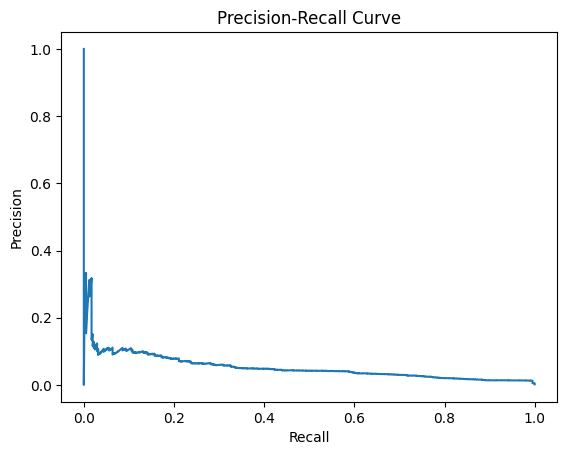

In [635]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [637]:
pd.Series(brf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

Payment Format          0.28
high_risk_format_flag   0.21
txn_per_day             0.09
txn_7d                  0.08
rolling_volatility_7d   0.07
txn_sum_7d              0.07
hour                    0.03
log_amount              0.03
in_out_ratio            0.03
avg_amount_paid         0.03
log_amount_received     0.02
log_amount_paid         0.02
amount_zscore           0.02
Receiving Currency      0.01
Payment Currency        0.01
dayofweek               0.00
dtype: float64

In [638]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    brf,
    X_test,
    y_test,
    scoring="recall",
    n_repeats=5,
    random_state=42
)

pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

Payment Format          0.64
high_risk_format_flag   0.64
txn_sum_7d              0.00
log_amount              0.00
log_amount_paid         0.00
Payment Currency        0.00
in_out_ratio            0.00
Receiving Currency      0.00
amount_zscore           0.00
rolling_volatility_7d   0.00
txn_7d                  0.00
log_amount_received     0.00
hour                    0.00
dayofweek               0.00
avg_amount_paid         0.00
txn_per_day             0.00
dtype: float64